<a href="https://colab.research.google.com/github/Andrei0031/capstone-watersync/blob/master/notebooks/libraries/RevenueForecasting_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statsmodels

In [ ]:
!pip install prophet

In [6]:
from google.colab import files
uploaded = files.upload()

# ... (the rest of the code starts here)
import pandas as pd
# ...

# ==========================================
# STEP 1: LOAD AND PREPROCESS THE DATA
# ==========================================
df = pd.read_csv('dummy_meter_readings_200.csv')
df['Consumption'] = df['Current Reading'] - df['Previous Reading']

# --- NEW TIERED BILLING LOGIC ---
def calculate_revenue(consumption):
    if consumption <= 6:
        return 100.0  # Base fee of 100 PHP for the first 6 cubic meters
    else:
        excess = consumption - 6
        return 100.0 + (excess * 20.0) # Base fee + 20 PHP per excess cubic meter

# Apply the custom rule to every single row in the dataset
df['Revenue'] = df['Consumption'].apply(calculate_revenue)
# --------------------------------

# Convert 'Reading Date' from text to an actual DateTime format
df['Reading Date'] = pd.to_datetime(df['Reading Date'])

# (The rest of the code stays exactly the same...)

Saving dummy_meter_readings_200.csv to dummy_meter_readings_200 (2).csv


Training the Advanced ML Model...
Training Complete!



/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


--- Future Forecast (Next 6 Months) ---
           ds           yhat     yhat_lower     yhat_upper
35 2025-11-30   19780.901037   19332.545007   20215.534786
36 2025-12-31 -204419.498508 -204857.822552 -203976.789535
37 2026-01-31   19249.100808   18835.945618   19692.493329
38 2026-02-28   19884.091534   19435.658763   20327.038889
39 2026-03-31   18677.814012   18223.558259   19116.549672
40 2026-04-30  -28835.745862  -29296.842850  -28404.028567


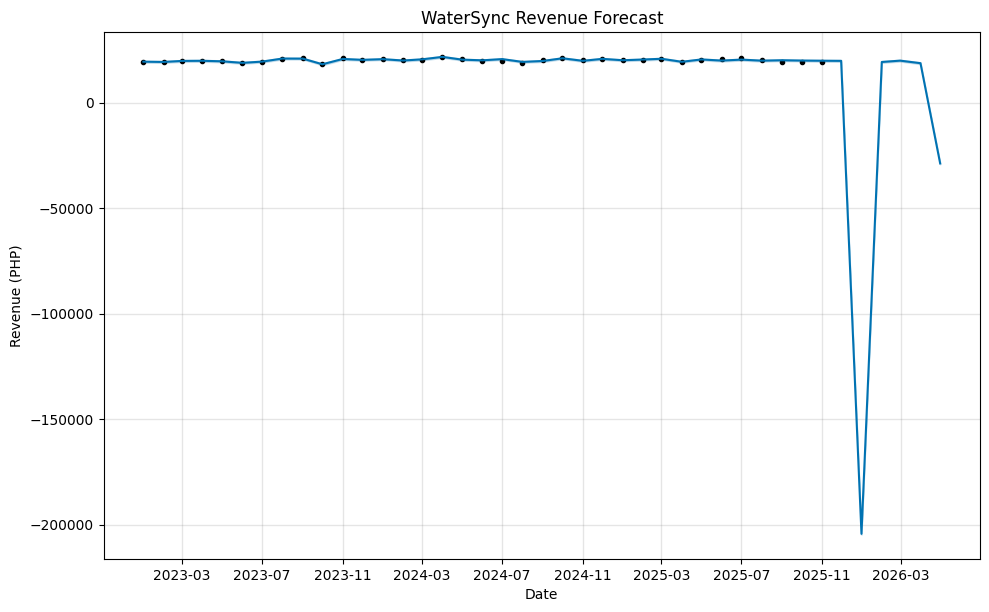

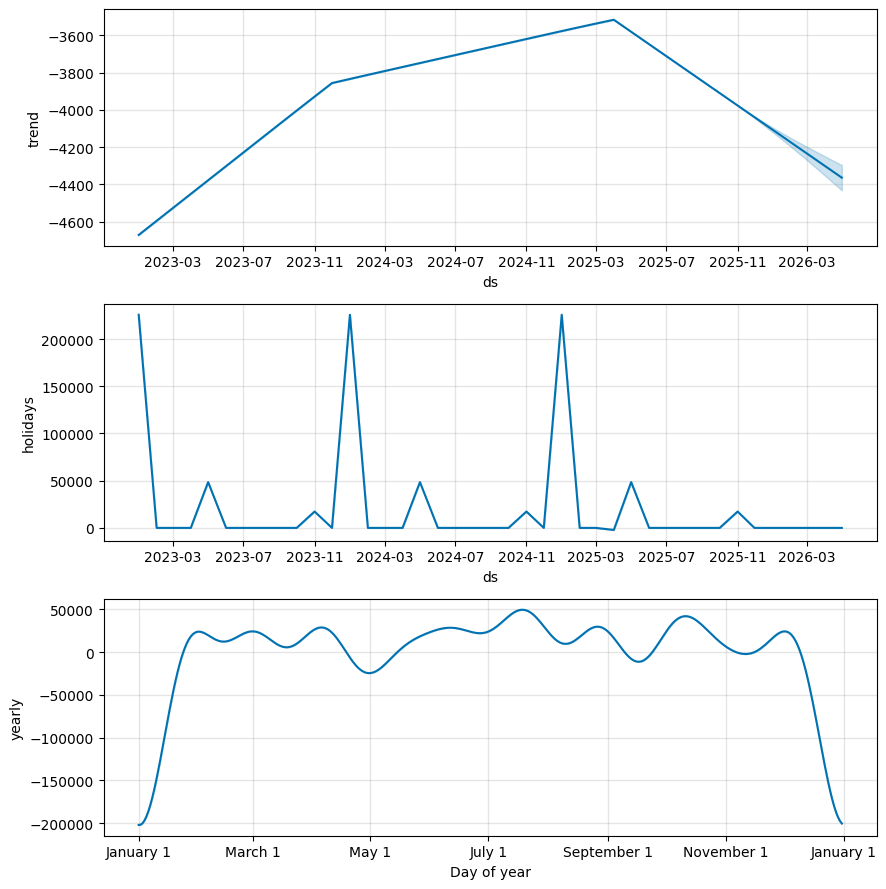

INFO:prophet:Making 28 forecasts with cutoffs between 2023-07-15 00:00:00 and 2025-10-02 00:00:00



Running Accuracy Tests (Cross-Validation)... This may take a moment.


  0%|          | 0/28 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 4.
INFO:prophet:n_changepoints greater than number of observations. Using 5.
INFO:prophet:n_changepoints greater than number of observations. Using 6.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
INFO:prophet:n_changepoints greater than number of observations. Using 9.
INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 11.
INFO:prophet:n_changepoints greater than number of observations. Using 12.
INFO:prophet:n_changepoints greater than number of observations. Using 13.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints grea


--- AI Accuracy Metrics ---
  horizon           rmse      mape
0 18 days  194531.689162  8.997831
1 19 days  134220.167833  5.889538
2 20 days   45487.957608  1.614478
3 21 days    5810.571452  0.237021
4 22 days    9306.734696  0.356484


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


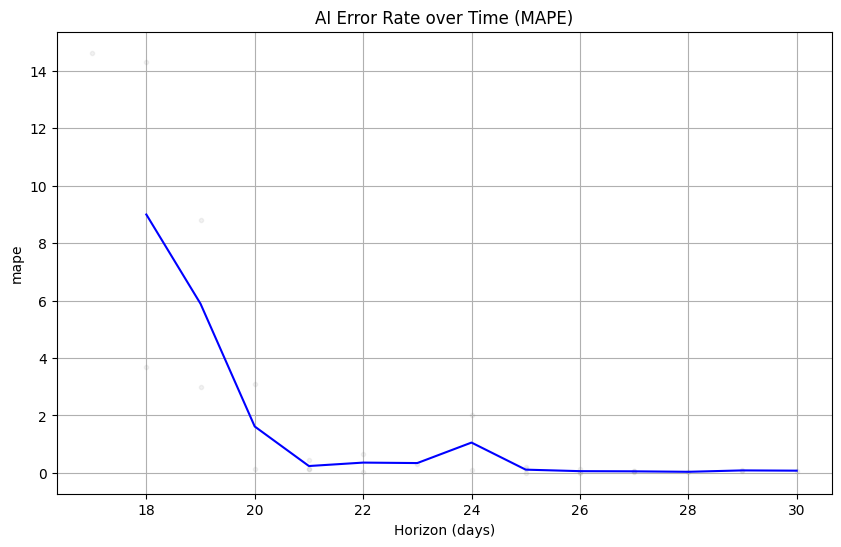

In [7]:
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt

df = pd.read_csv('dummy_meter_readings_200.csv')
df['Consumption'] = df['Current Reading'] - df['Previous Reading']
df['Revenue'] = df['Consumption'] * 25.0
df['Reading Date'] = pd.to_datetime(df['Reading Date'])

monthly_data = df.groupby(df['Reading Date'].dt.to_period('M'))['Revenue'].sum().reset_index()
monthly_data['Reading Date'] = monthly_data['Reading Date'].dt.to_timestamp()

prophet_df = pd.DataFrame({
    'ds': monthly_data['Reading Date'],
    'y': monthly_data['Revenue']
})

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.add_country_holidays(country_name='PH')

print("Training the Advanced ML Model...")
model.fit(prophet_df)
print("Training Complete!\n")

future_calendar = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future_calendar)

print("--- Future Forecast (Next 6 Months) ---")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))

fig1 = model.plot(forecast)
plt.title("WaterSync Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue (PHP)")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

print("\nRunning Accuracy Tests (Cross-Validation)... This may take a moment.")
try:
    df_cv = cross_validation(model, initial='180 days', period='30 days', horizon='30 days')
    df_p = performance_metrics(df_cv)

    print("\n--- AI Accuracy Metrics ---")
    print(df_p[['horizon', 'rmse', 'mape']].head())

    fig3 = plot_cross_validation_metric(df_cv, metric='mape')
    plt.title("AI Error Rate over Time (MAPE)")
    plt.show()

except Exception as e:
    print("\nNote: Not enough years of dummy data to run Cross-Validation testing.")
    print("Add more historical months to your CSV to unlock Accuracy Testing!")

Statsmodels is a Python module that allows users to explore data, estimate statistical models, and perform statistical tests. An extensive list of descriptive statistics, statistical tests, plotting functions, and result statistics are available for different types of data and each estimator.

Library documentation: <a>http://statsmodels.sourceforge.net/</a>